In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install numpy
!pip install -U "cupy-cuda13x[ctk]"
!pip install types-array-api
!pip install array-api-compat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 MB 3.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 MB 19.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 MB 6.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 MB 19.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.7/244.7 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 MB 6.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 MB 20.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-toolkit
    Found existing installation: cuda-toolkit 12.8.1
    Uninstalling cuda-toolkit-12.8.1:
      Successfully uninstalled cuda-toolkit-12.8.1
ERROR: pip's depend

In [2]:
!git clone https://github.com/Ankit-539/QuanSToS.git

Cloning into 'QuanSToS'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 121 (delta 73), reused 59 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 105.40 KiB | 467.00 KiB/s, done.
Resolving deltas: 100% (73/73), done.


In [3]:
%cd QuanSToS

/content/QuanSToS


In [4]:
from time import perf_counter

import cupy as cp
import numpy as np
import array_api_compat
import math

from src import (
    get_random_haar,
    get_random_mixed,
    get_random_product,
    inverse_estimator,
    mle,
    fidelity,
    pauli_measurement,
    plot_counts
)

XXX  [12377 12439 12604 12663 12328 12443 12558 12588]
XXY  [12516 12603 12704 12166 12354 12612 12571 12474]
XXZ  [21177  3801 21372  3805 21169  3770 21124  3782]
XYX  [12456 12467 12350 12573 12461 12565 12687 12441]
XYY  [12472 12452 12625 12454 12502 12405 12673 12417]
XYZ  [21113  3650 21404  3665 21188  3854 21306  3820]
XZX  [21501 21047  3686  3696 21116 21417  3770  3767]
XZY  [21098 21485  3797  3751 21130 21294  3673  3772]
XZZ  [38680  3769  3734  3743 38790  3754  3859  3671]
YXX  [12470 12453 12577 12564 12423 12396 12508 12609]
YXY  [12384 12352 12607 12589 12430 12438 12651 12549]
YXZ  [21271  3686 21242  3715 21018  3874 21389  3805]
YYX  [12549 12470 12555 12613 12582 12141 12567 12523]
YYY  [12477 12409 12629 12517 12612 12594 12379 12383]
YYZ  [21379  3708 21303  3734 21186  3665 21210  3815]
YZX  [21204 21095  3781  3777 21249 21349  3755  3790]
YZY  [21247 21232  3713  3770 21118 21442  3786  3692]
YZZ  [38798  3721  3866  3773 38669  3720  3680  3773]
ZXX  [2143

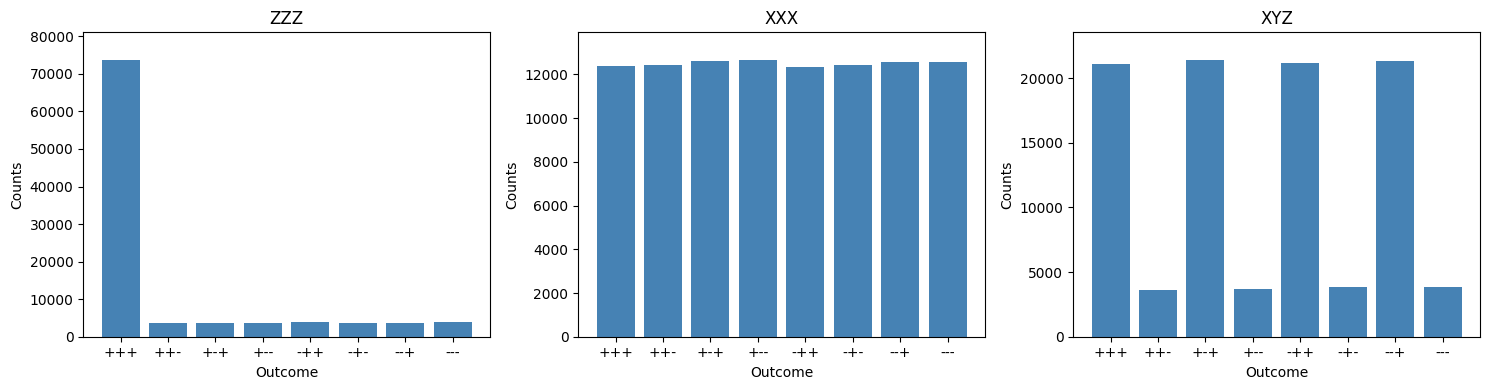

In [5]:
p = 0.7
rho_000 = np.zeros((8, 8), dtype=np.complex128)
rho_000[0, 0] = 1
rho_partial = ( p*rho_000 + (1-p)*np.eye(8, dtype=np.complex128)/8)

N = 100_000

result = pauli_measurement(rho_partial, N)

print(result)

plot_counts(result,["ZZZ", "XXX", "XYZ"])

XXX  [12524 12715 12641 12375 12424 12249 12571 12501]
XXY  [12471 12509 12441 12320 12322 12686 12637 12614]
XXZ  [24880     0 24939     0 25225     0 24956     0]
XYX  [12623 12535 12471 12564 12578 12345 12490 12394]
XYY  [12476 12390 12390 12448 12612 12522 12419 12743]
XYZ  [24968     0 25231     0 24889     0 24912     0]
XZX  [25137 25091     0     0 25180 24592     0     0]
XZY  [25017 24812     0     0 25034 25137     0     0]
XZZ  [50005     0     0     0 49995     0     0     0]
YXX  [12472 12503 12489 12379 12383 12668 12452 12654]
YXY  [12424 12495 12383 12438 12571 12446 12652 12591]
YXZ  [24957     0 24989     0 25255     0 24799     0]
YYX  [12439 12649 12481 12330 12483 12633 12511 12474]
YYY  [12323 12512 12544 12596 12613 12221 12535 12656]
YYZ  [24812     0 24969     0 25048     0 25171     0]
YZX  [24977 25164     0     0 24699 25160     0     0]
YZY  [25051 25011     0     0 25129 24809     0     0]
YZZ  [49825     0     0     0 50175     0     0     0]
ZXX  [2488

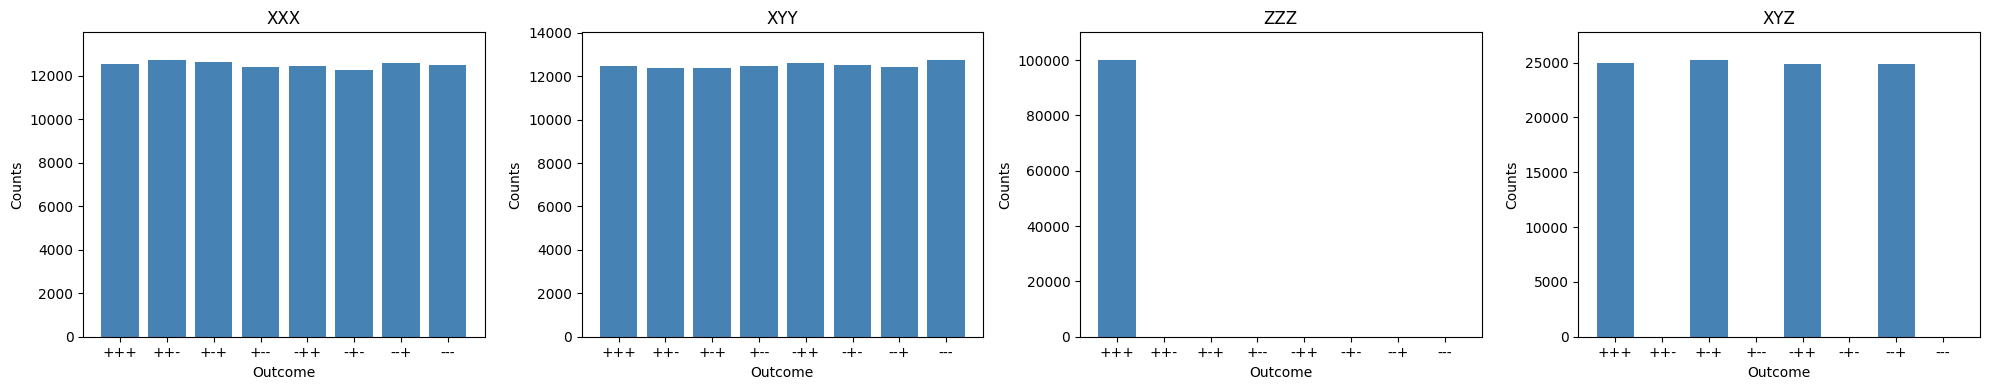

In [6]:
rho_000_cp = cp.zeros((8, 8), dtype=cp.complex128)
rho_000_cp[0, 0] = 1

N = 100_000

result_cp = pauli_measurement(rho_000_cp, N)

print(result_cp)
plot_counts(
    result_cp,
    ["XXX", "XYY", "ZZZ", "XYZ"]
)

100000


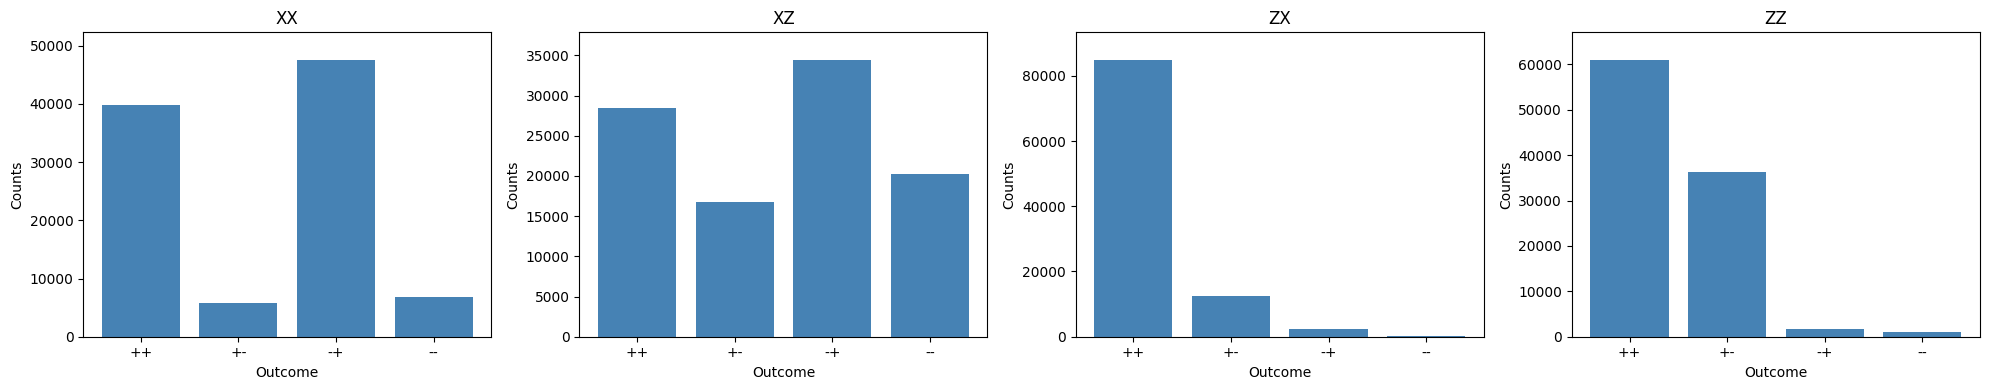

In [16]:
rho = get_random_product(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

100000


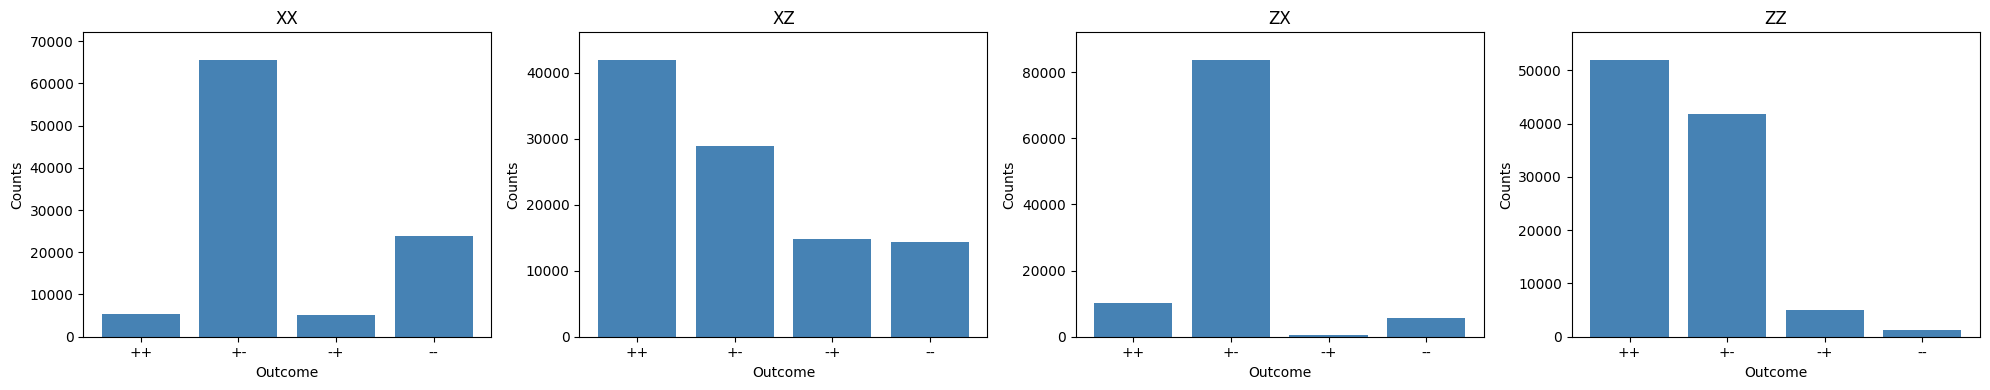

In [18]:
rho = get_random_haar(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

In [12]:
rho.shape

(4, 4)

# Hardware Benchmarking

### CPU (NumPy)

### GPU (CuPy)

# Noise Resilience

In [ ]:
# Here, we can make a plot with the number of
# shots (N) on the x axis and fidelity (F) on the y axis.

# Advanced Protocols (Classical Shadows)